In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.utils import load_sweep_metadata, load_data
import pandas as pd
import torch


## At some point 

In [ ]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector

In [ ]:
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [ ]:
from tdmpc2 import TDMPC2

In [ ]:
# Base configuration for state-based environment
CKPT_TO_USE = 500_000
CKPT_PATH_STATE = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
CKPT_PATH_RGB = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

override_cfg_rgb = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_RGB,
    obs='rgb',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create RGB-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_rgb = compose(config_name="config")
    OmegaConf.set_struct(cfg_rgb, False)
    cfg_rgb = OmegaConf.merge(cfg_rgb, override_cfg_rgb)

cfg_rgb = parse_cfg(cfg_rgb)
set_seed(cfg_rgb.seed)

cfg_rgb.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_rgb = make_env(cfg_rgb)

print("\nLoading RGB-based agent...")
agent_rgb = TDMPC2(cfg_rgb)
if hasattr(cfg_rgb, 'checkpoint') and cfg_rgb.checkpoint:
    print(f"Loading checkpoint: {cfg_rgb.checkpoint}")
    agent_rgb.load(cfg_rgb.checkpoint)

# Create state-based environment
with initialize(config_path="tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = TDMPC2(cfg_state)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading RGB-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2026-01-15/21-56-52/cartpole_exp_pixel/models/650000.pt

Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [ ]:
def sample_uniform_obs(n):
    """
    Sample n observations uniformly from the following bounds:
    - position:         [-1.5, 1.5]
    - cos:              [-1.0, 1.0]
    - sin:              [-1.0, 1.0]
    - art velocity:     [-2.5, 2.5]
    - angular velocity: [-7.5, 7.5]
    Returns:
        obs: numpy array of shape [n, 5]
    """
    bounds = np.array([
        [-1.5, 1.5],  # position
        [0, 360],  # angle
        #[-1.0, 1.0],  # cos
        #[-1.0, 1.0],  # sin
        [-2.5, 2.5],  # cart velocity
        [-7.5, 7.5],  # angular velocity
    ])
    obs = np.random.uniform(bounds[:, 0],
                            bounds[:, 1],
                            size=(n, bounds.shape[0]))
    return obs


number_of_samples = 10_000
obs_uniform_angle = sample_uniform_obs(number_of_samples)


In [ ]:
obs_uniform = np.zeros((number_of_samples, 5))
obs_uniform[:, 0] = obs_uniform_angle[:, 0]
obs_uniform[:, 1] = np.cos(np.deg2rad(obs_uniform_angle[:, 1]))
obs_uniform[:, 2] = np.sin(np.deg2rad(obs_uniform_angle[:, 1]))
obs_uniform[:, 3] = obs_uniform_angle[:, 2]
obs_uniform[:, 4] = obs_uniform_angle[:, 3]


In [ ]:
steps = 3

total_obs = []
for initial_condition in tqdm(obs_uniform):
    obs = env_state.reset(
        initial_state={
            'qpos': {
                'slider':
                    initial_condition[0],
                'hinge_1':
                    np.arctan2(initial_condition[2], initial_condition[1]),
            },
            'qvel': {
                'slider': initial_condition[3],
                'hinge_1': initial_condition[4],
            },
        })
    obs_with_policy = [obs.numpy()]
    for _ in range(steps - 1):
        action = agent_state.act(obs)
        obs, reward, done, info = env_state.step(action)
        obs_with_policy.append(obs.numpy())
    total_obs.append(obs_with_policy)

100%|██████████| 10000/10000 [07:24<00:00, 22.48it/s]


In [ ]:
obs_final = []
for obs_with_policy in total_obs:
    frames = reconstruct_cartpole_dmcontrol(np.array(obs_with_policy),
                                            height=64,
                                            width=64,
                                            save_video=False,
                                            return_frames=True)
    obs_with_policy_frames = np.array(frames).transpose(0, 3, 1,
                                                        2).reshape(-1, 64, 64)
    obs_final.append(obs_with_policy_frames)

100%|██████████| 3/3 [00:00<00:00, 23.31it/s]


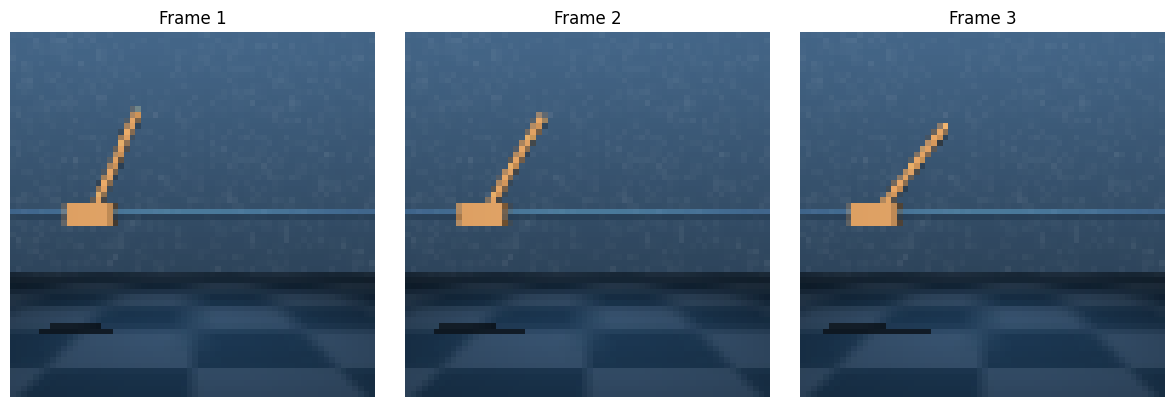

In [ ]:
frame1 = obs_with_policy_frames[:3]
frame2 = obs_with_policy_frames[3:6]
frame3 = obs_with_policy_frames[6:9]

import matplotlib.pyplot as plt
# Bring frame1, frame2, frame3 to cpu and convert to numpy for plotting
f1 = frame1
f2 = frame2
f3 = frame3

plt.figure(figsize=(12, 4))
for i, f in enumerate([f1, f2, f3]):
    plt.subplot(1, 3, i + 1)
    # Move channel axis to last (C, H, W) -> (H, W, C)
    img = f.transpose(1, 2, 0)
    plt.imshow(img.astype(np.uint8))
    plt.axis('off')
    plt.title(f'Frame {i+1}')
plt.tight_layout()
plt.show()

In [ ]:
frames_final_stacked_torch = torch.from_numpy(
    np.array(obs_final)).to('cuda').float()
frames_final_stacked_torch.shape

torch.Size([10000, 9, 64, 64])

In [ ]:
# torch.save(
#     frames_final_stacked_torch,
#     "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/frames_uniform_data.pt"
# )

frames_final_stacked_torch = torch.load(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/data_generation/frames_uniform_data.pt"
)


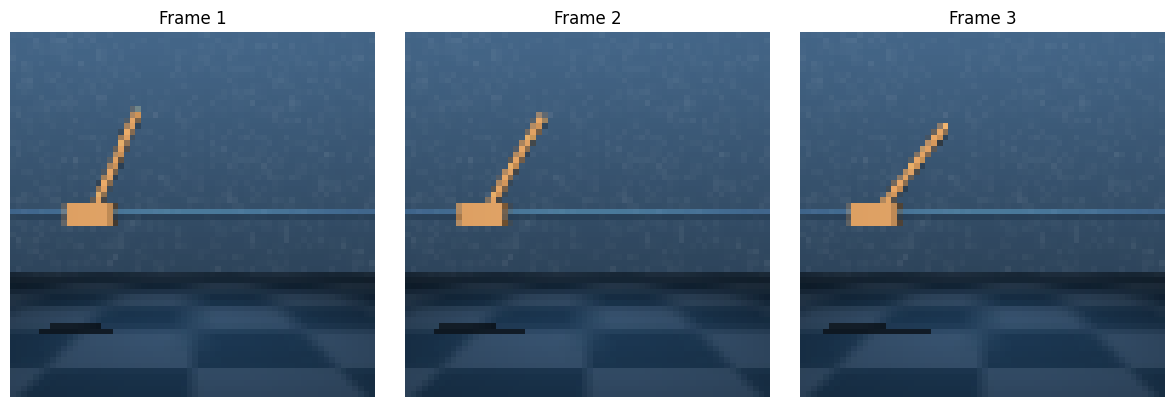

In [ ]:
frame1 = frames_final_stacked_torch[-1][:3]
frame2 = frames_final_stacked_torch[-1][3:6]
frame3 = frames_final_stacked_torch[-1][6:9]

import matplotlib.pyplot as plt
# Bring frame1, frame2, frame3 to cpu and convert to numpy for plotting
f1 = frame1.cpu().numpy()
f2 = frame2.cpu().numpy()
f3 = frame3.cpu().numpy()

plt.figure(figsize=(12, 4))
for i, f in enumerate([f1, f2, f3]):
    plt.subplot(1, 3, i + 1)
    # Move channel axis to last (C, H, W) -> (H, W, C)
    img = f.transpose(1, 2, 0)
    plt.imshow(img.astype(np.uint8))
    plt.axis('off')
    plt.title(f'Frame {i+1}')
plt.tight_layout()
plt.show()

In [ ]:
# # For each frame, append the same image 3 times along the channel (dim=1)
# frames_list = []
# n = frames_torch.shape[0]
# for i in range(n):
#     f = frames_torch[i]
#     stacked = torch.cat([f, f, f], dim=0)  # shape (C*3, H, W)
#     frames_list.append(stacked)
# frames_stacked_torch = torch.stack(frames_list, dim=0)  # (n, C*3, H, W)

In [ ]:
# obs_all_np = np.concatenate(
#     [obs_inpolicy, obs_offpolicy, obs_passive, obs_uniform], axis=0)
# obs_all = torch.from_numpy(obs_all_np).to('cuda')

# # Permute (shuffle) the time axis (assume axis=0) of obs_all
# perm = torch.randperm(obs_all.shape[0], device=obs_all.device)
# obs_all = obs_all[perm]

#obs_uniform_torch = torch.from_numpy(obs_uniform).to('cuda').float()
# z_torch_state = agent_state.model.encode(obs_uniform_torch,
#                                          task=None).detach().cpu()
z_torch_rgb = agent_rgb.model.encode(frames_final_stacked_torch,
                                     task=None).detach().cpu()
#obs_torch = obs_uniform_torch.detach().cpu()

In [ ]:
z_torch_rgb.shape

torch.Size([10000, 512])

In [33]:
save_directory = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data'

projectors = {}
# PCA
#10, 30, 50, 75, 100
for k in [150]:
    projector = LatentProjector.fit(
        z_torch_rgb,
        k=k,
        method='pca',
    )
    path = f"{save_directory}/pixelv2_pca_projector_k{k}.pt"
    projector.save(path)
    print(f"Saved PCA projector with k={k} to {path}")
    projectors[f"pca_k{k}"] = projector

# # Hybrid CCA: 5 state-predictive directions
# for k_unsupervised in [5, 6, 7, 8, 9, 10, 15]:
#     k_supervised = 5
#     projector = LatentProjector.fit(z_torch,
#                                     k=k_unsupervised + k_supervised,
#                                     method='hybrid_ols',
#                                     states=obs_torch,
#                                     k_supervised=k_supervised,
#                                     ridge=1e-4)
#     path = f"{save_directory}/hybrid_ols_projector_k{k_unsupervised}_k_supervised{k_supervised}.pt"
#     projector.save(path)
#     print(
#         f"Saved hybrid OLS projector with k_unsupervised={k_unsupervised} and k_supervised={k_supervised} to {path}"
#     )

# Supervised CCA
# projector = LatentProjector.fit(z_torch_rgb,
#                                 k=5,
#                                 method='cca',
#                                 states=obs_torch[:10_000],
#                                 k_supervised=5,
#                                 ridge=1e-4)
# projector.save(f"{save_directory}/pixel_cca_projector_k5.pt")
# print(
#     f"Saved CCA projector with k=5 to {save_directory}/pixel_cca_projector_k5.pt"
# )

train_latents = z_torch_rgb[:9000]
test_latents = z_torch_rgb[9000:]
for k in [150]:
    print(f"\n=== Fitting NonlinearLatentProjector with k={k} ===")
    projector = NonlinearLatentProjector.fit(
        train_latents,
        test_latents,
        k=k,
        hidden_dims=[256, 128],
        epochs=5000,
        early_stopping_patience=100,
    )
    projectors[f"nonlinear_k{k}"] = projector
    path = f"{save_directory}/pixelv2_nonlinear_projector_k{k}.pt"
    projector.save(path)
    print(f"Saved nonlinear projector with k={k} to {path}")

LatentProjector.fit (pca): k=150, explained_var=0.9527
LatentProjector (pca) saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_pca_projector_k150.pt
Saved PCA projector with k=150 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_pca_projector_k150.pt

=== Fitting NonlinearLatentProjector with k=150 ===


Fitting k=150: 100%|█████████▉| 4975/5000 [04:48<00:01, 17.27it/s, test=0.061065, train=0.047753]


Early stopping at epoch 4976
NonlinearLatentProjector.fit: k=150, train_R²=0.9522, test_R²=0.9393 (N_train=9000, N_test=1000)
NonlinearLatentProjector saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_nonlinear_projector_k150.pt
Saved nonlinear projector with k=150 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_nonlinear_projector_k150.pt


In [ ]:
z_torch_rgb

tensor([[0.0403, 0.1098, 0.1526,  ..., 0.2387, 0.2402, 0.0966],
        [0.1215, 0.2212, 0.2850,  ..., 0.0958, 0.1163, 0.0267],
        [0.0214, 0.0562, 0.1642,  ..., 0.3271, 0.1523, 0.2176],
        ...,
        [0.1353, 0.2181, 0.2801,  ..., 0.6465, 0.1219, 0.0149],
        [0.1252, 0.2663, 0.0897,  ..., 0.1445, 0.2289, 0.4099],
        [0.6407, 0.1235, 0.0237,  ..., 0.1518, 0.1192, 0.2122]])

In [ ]:
projectors.keys()

dict_keys(['pca_k10', 'pca_k30', 'pca_k50', 'pca_k75', 'pca_k100', 'nonlinear_k75'])

In [ ]:
for p in projectors.values():
    print(p.explained_variance_ratio(z_torch_rgb[9000:].cuda()))

0.5551567077636719
0.7444356679916382
0.8257981538772583
0.8814318776130676
0.9143730998039246
0.9380798935890198


In [36]:
from pathlib import Path

PROJECTORS_DIR = Path(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data'
)


def get_projector_configs():
    """
    Define all projector configurations to sweep over.
    
    Returns list of dicts with:
        - name: Human-readable name for the config
        - path: Path to the projector file
        - type: 'linear' or 'nonlinear'
    """
    configs = []

    # PCA
    for k in [10, 30, 50, 75, 100, 150]:
        configs.append({
            'name': f'pca_k{k}',
            'path': PROJECTORS_DIR / f'pixelv2_pca_projector_k{k}.pt',
            'type': 'linear',
            'method': 'pca',
            'k': k,
        })

    # Nonlinear projectors: k = 3, 4, 5, 6, 7, 8, 10, 15
    for k in [10, 30, 40, 100, 150]:
        configs.append({
            'name': f'nonlinear_k{k}',
            'path': PROJECTORS_DIR / f'pixelv2_nonlinear_projector_k{k}.pt',
            'type': 'nonlinear',
            'method': 'nonlinear',
            'k': k,
        })

    return configs


def load_projector(config):
    """Load a projector from disk based on config."""
    path = config['path']
    if not path.exists():
        raise FileNotFoundError(
            f"Projector not found: {path}\n"
            f"Please fit projectors first and save them to {PROJECTORS_DIR}")

    if config['type'] == 'linear':
        return LatentProjector.load(str(path))
    else:  # nonlinear
        return NonlinearLatentProjector.load(str(path))


In [40]:
data = torch.load(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-23-cartpole_swingup-projected_sweep_uniform_data/pixelv2_pca_projector_k150.pt'
)

LatentProjector loaded: method=pca, k=10, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=30, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=50, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=75, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=100, latent_dim=512, device=cuda
LatentProjector loaded: method=pca, k=150, latent_dim=512, device=cuda
NonlinearLatentProjector loaded: k=10, latent_dim=512
NonlinearLatentProjector loaded: k=30, latent_dim=512
NonlinearLatentProjector loaded: k=40, latent_dim=512
NonlinearLatentProjector loaded: k=100, latent_dim=512
NonlinearLatentProjector loaded: k=150, latent_dim=512


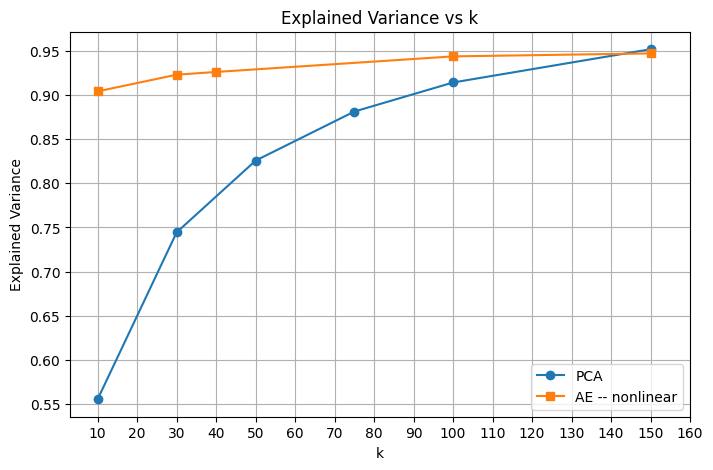

In [37]:
import matplotlib.pyplot as plt

configs = get_projector_configs()

k_values_pca = []
explained_var_pca = []
k_values_nonlinear = []
explained_var_nonlinear = []

for config in configs:
    projector = load_projector(config)
    k = config['k']
    if config['type'] == 'linear':
        explained_var = projector.explained_variance_ratio(
            z_torch_rgb[9000:].cuda())
        k_values_pca.append(k)
        explained_var_pca.append(explained_var)
    elif config['type'] == 'nonlinear':
        explained_var = projector.explained_variance_ratio(
            z_torch_rgb[9000:].cuda())
        k_values_nonlinear.append(k)
        explained_var_nonlinear.append(explained_var)

# Sort data for plotting
if k_values_pca:
    pca_sorted = sorted(zip(k_values_pca, explained_var_pca))
    k_values_pca, explained_var_pca = zip(*pca_sorted)
if k_values_nonlinear:
    nonlinear_sorted = sorted(zip(k_values_nonlinear, explained_var_nonlinear))
    k_values_nonlinear, explained_var_nonlinear = zip(*nonlinear_sorted)

plt.figure(figsize=(8, 5))
plt.plot(k_values_pca, explained_var_pca, marker='o', label='PCA')
plt.plot(k_values_nonlinear,
         explained_var_nonlinear,
         marker='s',
         label='AE -- nonlinear')
plt.xlabel('k')
plt.ylabel('Explained Variance')
plt.title('Explained Variance vs k')
plt.legend()
plt.grid(True)

# Add x-ticks every 10 on the x-axis
all_k = list(k_values_pca) + list(k_values_nonlinear)
if all_k:
    min_k, max_k = min(all_k), max(all_k)
    xticks = list(range(((min_k // 10) * 10), ((max_k // 10 + 1) * 10 + 1), 10))
    plt.xticks(xticks)

plt.show()
